## Model Traning and Evaluation

#### New notebook for ML tasks for data science acellerator to keep notesbooks small and tidy.

In [154]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error

np.random.seed(42)

In [155]:
#define the function to plot the learning curve
def plot_learning_curve(
    estimator,
    title,
    X,
    y,
    axes=None,
    ylim=None,
    cv=None,
    n_jobs=None,
    train_sizes=np.linspace(0.1, 1.0, 5),
):
    """
    Generate 3 plots: the test and training learning curve, the training
    samples vs fit times curve, the fit times vs score curve.

    Parameters
    ----------
    estimator : estimator instance
        An estimator instance implementing `fit` and `predict` methods which
        will be cloned for each validation.

    title : str
        Title for the chart.

    X : array-like of shape (n_samples, n_features)
        Training vector, where ``n_samples`` is the number of samples and
        ``n_features`` is the number of features.

    y : array-like of shape (n_samples) or (n_samples, n_features)
        Target relative to ``X`` for classification or regression;
        None for unsupervised learning.

    axes : array-like of shape (3,), default=None
        Axes to use for plotting the curves.

    ylim : tuple of shape (2,), default=None
        Defines minimum and maximum y-values plotted, e.g. (ymin, ymax).

    cv : int, cross-validation generator or an iterable, default=None
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:

          - None, to use the default 5-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, default=None
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like of shape (n_ticks,)
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the ``dtype`` is float, it is regarded
        as a fraction of the maximum size of the training set (that is
        determined by the selected validation method), i.e. it has to be within
        (0, 1]. Otherwise it is interpreted as absolute sizes of the training
        sets. Note that for classification the number of samples usually have
        to be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=train_sizes,
        return_times=True,
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes[0].grid()
    axes[0].fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="r",
    )
    axes[0].fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="g",
    )
    axes[0].plot(
        train_sizes, train_scores_mean, "o-", color="r", label="Training score"
    )
    axes[0].plot(
        train_sizes, test_scores_mean, "o-", color="g", label="Cross-validation score"
    )
    axes[0].legend(loc="best")

    # Plot n_samples vs fit_times
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, "o-")
    axes[1].fill_between(
        train_sizes,
        fit_times_mean - fit_times_std,
        fit_times_mean + fit_times_std,
        alpha=0.1,
    )
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")
    axes[1].set_title("Scalability of the model")

    # Plot fit_time vs score
    fit_time_argsort = fit_times_mean.argsort()
    fit_time_sorted = fit_times_mean[fit_time_argsort]
    test_scores_mean_sorted = test_scores_mean[fit_time_argsort]
    test_scores_std_sorted = test_scores_std[fit_time_argsort]
    axes[2].grid()
    axes[2].plot(fit_time_sorted, test_scores_mean_sorted, "o-")
    axes[2].fill_between(
        fit_time_sorted,
        test_scores_mean_sorted - test_scores_std_sorted,
        test_scores_mean_sorted + test_scores_std_sorted,
        alpha=0.1,
    )
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Performance of the model")

    return plt

In [156]:
# read in our processed dataset
df = pd.read_csv('./data/final_df.csv')
print(df.shape)
df.head()

(549900, 11)


,iso3_o,iso3_d,tradeflow_baci,gdp_o,gdp_d,pop_o,pop_d,gdp_per_cap_o,distw_harmonic,fta_wto,wto_o
0,Aruba,Afghanistan,NaN,14.718799,16.584140,4.621014,10.254067,10.097785,13193.0,0.0,0.0
1,Aruba,Afghanistan,NaN,14.765029,16.698643,4.624306,10.278682,10.140723,13193.0,0.0,0.0
2,Aruba,Afghanistan,NaN,NaN,16.836267,4.628730,10.303087,NaN,13193.0,0.0,0.0
3,Aruba,Afghanistan,NaN,NaN,16.826608,4.633865,10.327175,NaN,13193.0,0.0,0.0
4,Aruba,Afghanistan,NaN,NaN,16.813749,4.642418,10.396903,NaN,13193.0,0.0,0.0


In [157]:
# check size and amount of nulls
print(df.shape)
df.isnull().sum(axis=0)

(549900, 11)


iso3_o                 0
iso3_d                 0
tradeflow_baci    236107
gdp_o              91260
gdp_d              91260
pop_o              62010
pop_d              62010
gdp_per_cap_o      91260
distw_harmonic         0
fta_wto                0
wto_o                  0
dtype: int64

In [158]:
# can we see common trade routes with null traffic
null_countries = df[df['tradeflow_baci'].isnull()]['iso3_o'] + df[df['tradeflow_baci'].isnull()]['iso3_d']
print(f'Number of null routes: {len(null_countries)}')
null_countries.value_counts()

Number of null routes: 236107


ArubaAnguilla                               10
ArubaAlbania                                10
ArubaAndorra                                10
ArubaArmenia                                10
ArubaAmerican Samoa                         10
                                            ..
ZimbabweParaguay                             1
ZimbabweQatar                                1
ZimbabweSeychelles                           1
ZimbabweSaint Vincent and the Grenadines     1
ZimbabweVietnam                              1
Name: count, Length: 32330, dtype: int64

In [159]:
# drop nulls due to sparcity (some countries have too little data to impute/ffill)
df = df.dropna()
df.shape

(271951, 11)

In [160]:
df.head()

,iso3_o,iso3_d,tradeflow_baci,gdp_o,gdp_d,pop_o,pop_d,gdp_per_cap_o,distw_harmonic,fta_wto,wto_o
7,Aruba,Afghanistan,5.076198,14.944387,16.746889,4.657393,10.499466,10.286994,13184.0,0.0,0.0
8,Aruba,Afghanistan,6.931335,14.979359,16.708835,4.661985,10.523309,10.317374,13184.0,0.0,0.0
9,Aruba,Afghanistan,6.087545,15.012476,16.749338,4.666359,10.546440,10.346116,13184.0,0.0,0.0
10,Aruba,Angola,10.824908,14.718799,18.227956,4.621014,9.880686,10.097785,9574.0,0.0,0.0
11,Aruba,Angola,-1.951928,14.765029,18.461015,4.624306,9.912472,10.140723,9574.0,0.0,0.0


In [161]:
# split into train test
X = df[['gdp_o', 'gdp_d', 'pop_o', 'pop_d', 'gdp_per_cap_o', 'distw_harmonic', 'fta_wto', 'wto_o']]
y = df['tradeflow_baci']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Can we setup a 'simple' baseline model for each model for benchmark score?
### We can also fit default models for various algorithms to check starting scores.

In [162]:
# loop through models to get basic cv scores
cv_scores_df = pd.DataFrame()

for model, model_name in zip([LinearRegression(), ElasticNet(), RandomForestRegressor(), GradientBoostingRegressor()],
                 ['linear_regression', 'elastic_net', 'random_forest', 'gradient_boost']):
    start = datetime.datetime.now()
    model_cv_score = cross_val_score(
        model, 
        X_train,
        y_train,
        scoring='neg_root_mean_squared_error',cv=5      
        )
    end = datetime.datetime.now()
    time_taken = end - start

    test_model =  model

    #fit/run gridsearch
    test_model.fit(X_train, y_train)

    # fit predict and measure best model
    
    y_pred = test_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)

    model_cv_score = -model_cv_score
    cv_scores_df = pd.concat([cv_scores_df, pd.DataFrame({
        'model': [model_name]*5,
        'scores': np.exp(model_cv_score),
        'test_score': np.exp(rmse),
        'time_taken': [time_taken.total_seconds()]*5
    }
        )]
    )

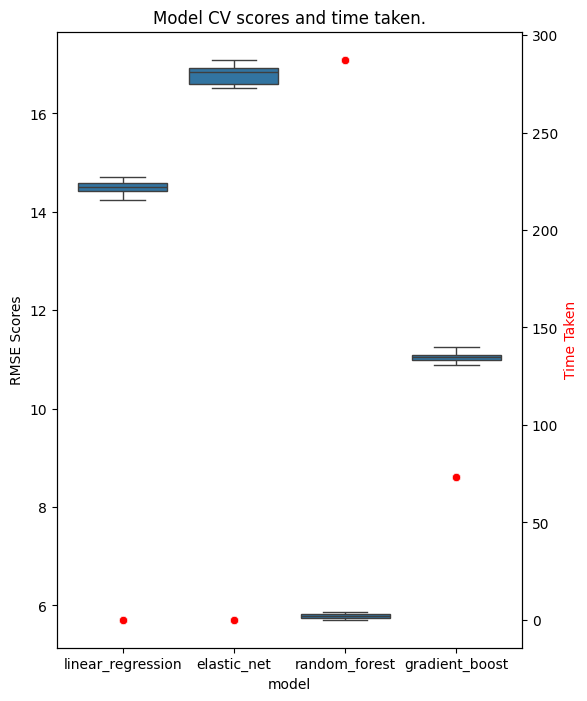

In [163]:
# plot cv scores as a box plot
fig, ax1 = plt.subplots(figsize=(6,8))
sns.boxplot(data=cv_scores_df, x='model', y='scores', ax=ax1)
ax1.set_ylabel('RMSE Scores')

#plot time taken for interest
ax2 = ax1.twinx()
plot = sns.scatterplot(data=cv_scores_df, x='model', y='time_taken', color='red', ax=ax2)
ax2.set_ylabel('Time Taken', color='red')
plt.title('Model CV scores and time taken.')
plt.show()

# Hyper Parameter Tuning

## Linear Regression

In [164]:
# create dataframe for tuned models
tuned_scores_df = pd.DataFrame()

# create a simple LR pipeline
lr_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ]
)

# simple gridcv params
params = {
    'regressor__positive': [True, False],
    'regressor__n_jobs': [None, 2, 3]
}

# run grid search
lr_grid = GridSearchCV(
    estimator= lr_pipeline, 
    param_grid=params,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1
)

#fit/run gridsearch
lr_grid.fit(X_train, y_train)

# fit predict and measure best model
best_lr_model = lr_grid.best_estimator_
y_pred = best_lr_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)

tuned_scores_df = pd.concat([tuned_scores_df, pd.DataFrame({
        'model': ['linear_regression']*5,
        'scores': np.exp(rmse)
    })])

print(f'Best Params for LR model: {lr_grid.best_params_}')
print(f'RMSE for LR transformed back: {np.exp(rmse)}')


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params for LR model: {'regressor__n_jobs': None, 'regressor__positive': False}
RMSE for LR transformed back: 14.569811032619084


In [165]:
def check_residuals(y_test, y_pred, title_suffix: str = None): 
    """
    Prints a histogram of a regression model's residuals during training.

    Parameters:
    model: The trained regression model.

    Returns:
    A histogram of the residuals.
    """

    # Get the residuals

    
    residuals = y_test - y_pred

    # Histogram of the Residuals
    plt.hist(residuals, bins=30, edgecolor='k')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Residuals (Log){' ' + title_suffix if title_suffix else ''}')
    return plt.show()

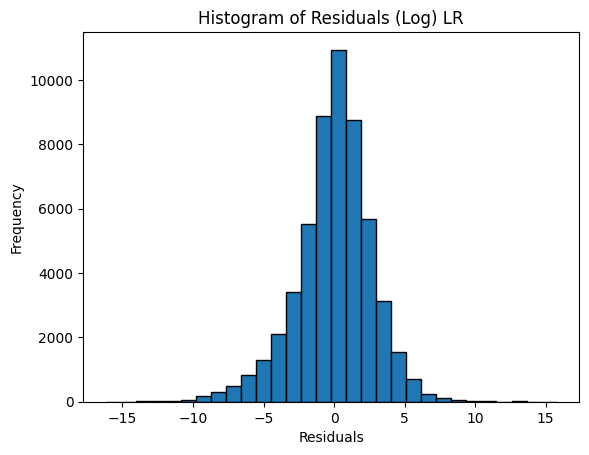

In [166]:
check_residuals(y_test, y_pred, 'LR')

#### Linear Regression Model gives very good accuracy for a simple model. We can start to look at other models to find out if they can improve upon LR's scores

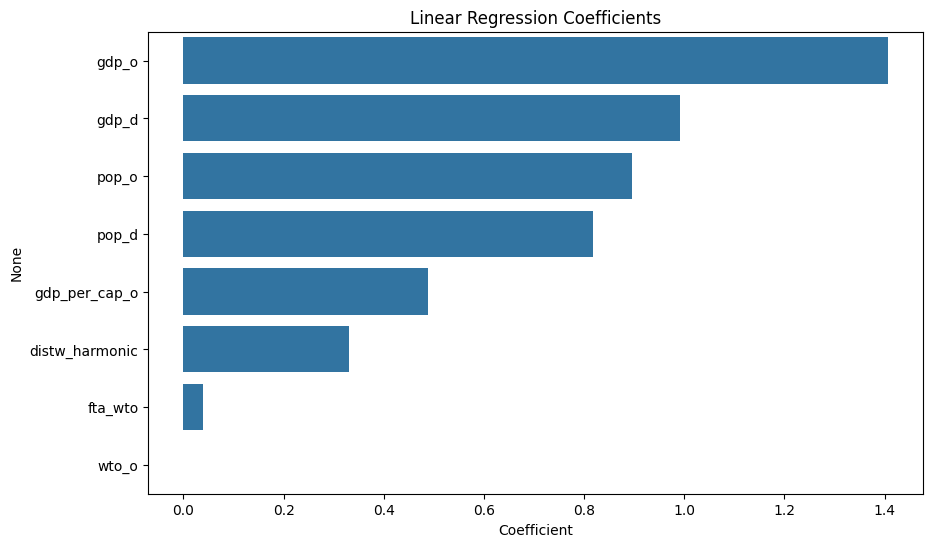

In [167]:
# can we find coefficients for the LR model?
lr_model = LinearRegression(**{'n_jobs': None, 'positive': False})
lr_model.fit(X_train, y_train)

#make df of coeff's
lr_coef = pd.DataFrame(lr_model.coef_, index=X.columns, columns=['Coefficient'])
lr_coef.sort_values(by='Coefficient', ascending=False)

# plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y=lr_coef.index, data=lr_coef.sort_values(by='Coefficient', ascending=False))
plt.title('Linear Regression Coefficients')
plt.show();

<module 'matplotlib.pyplot' from '/Users/danielcoles/Documents/Code/dc_accelerator/venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

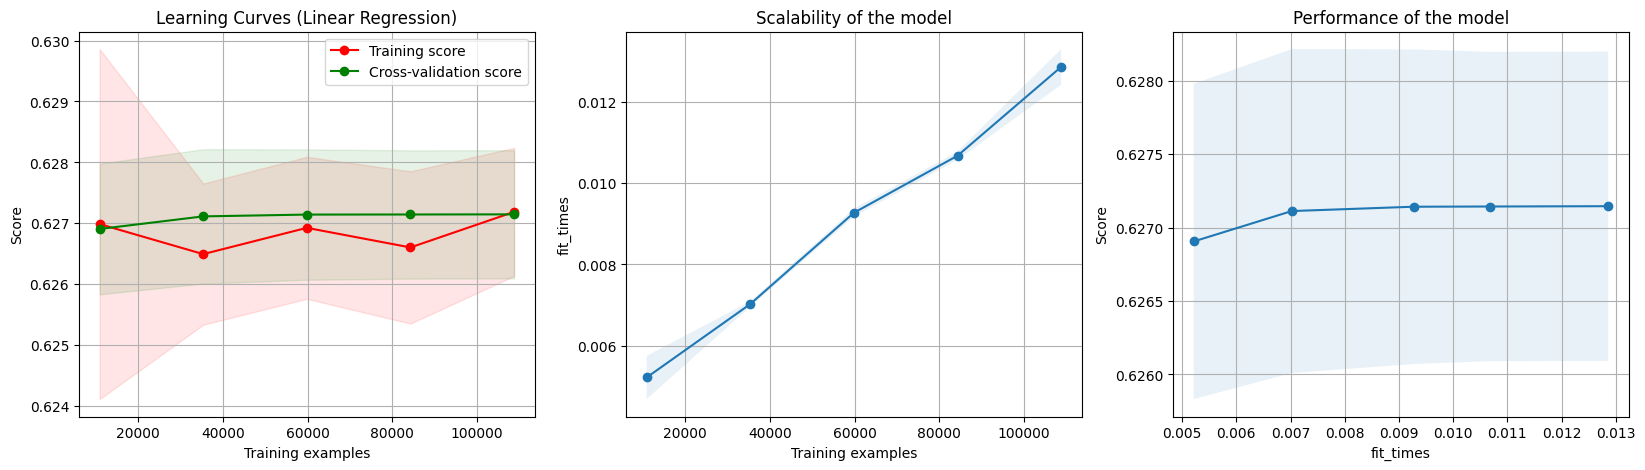

In [168]:
# plot learning curves of lr
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_learning_curve(best_lr_model, 'Learning Curves (Linear Regression)', X_train, y_train, axes=axes, cv=2, n_jobs=1)

## ElasticNet Regressor

In [169]:
# create a simple LR pipeline
en_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('regressor', ElasticNet())
    ]
)

# simple gridcv params
params = {
    'regressor__warm_start': [False, True],
    'regressor__l1_ratio': [0, 0.5, 1]
}

# run grid search
en_grid = GridSearchCV(
    estimator= en_pipeline, 
    param_grid=params,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1
)

#fit/run gridsearch
en_grid.fit(X_train, y_train)

# fit predict and measure best model
best_en_model = en_grid.best_estimator_
y_pred = best_en_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)

tuned_scores_df = pd.concat([tuned_scores_df, pd.DataFrame({
        'model': ['elastic_net']*5,
        'scores': np.exp(rmse)
    })])

print(f'Best Params for LR model: {en_grid.best_params_}')
print(f'RMSE for LR transformed back: {np.exp(rmse)}')

Fitting 5 folds for each of 6 candidates, totalling 30 fits


/Users/danielcoles/Documents/Code/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.040e+06, tolerance: 3.335e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/Users/danielcoles/Documents/Code/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.042e+06, tolerance: 3.348e+02
Linear regression models with a zero l1 penalization strength are more efficiently fi

Best Params for LR model: {'regressor__l1_ratio': 0, 'regressor__warm_start': False}
RMSE for LR transformed back: 20.731726240757748


/Users/danielcoles/Documents/Code/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.300e+06, tolerance: 4.171e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


/Users/danielcoles/Documents/Code/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.501e+04, tolerance: 2.095e+01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/Users/danielcoles/Documents/Code/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.128e+05, tolerance: 6.818e+01
Linear regression models with a zero l1 penalization strength are more efficiently fi

<module 'matplotlib.pyplot' from '/Users/danielcoles/Documents/Code/dc_accelerator/venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

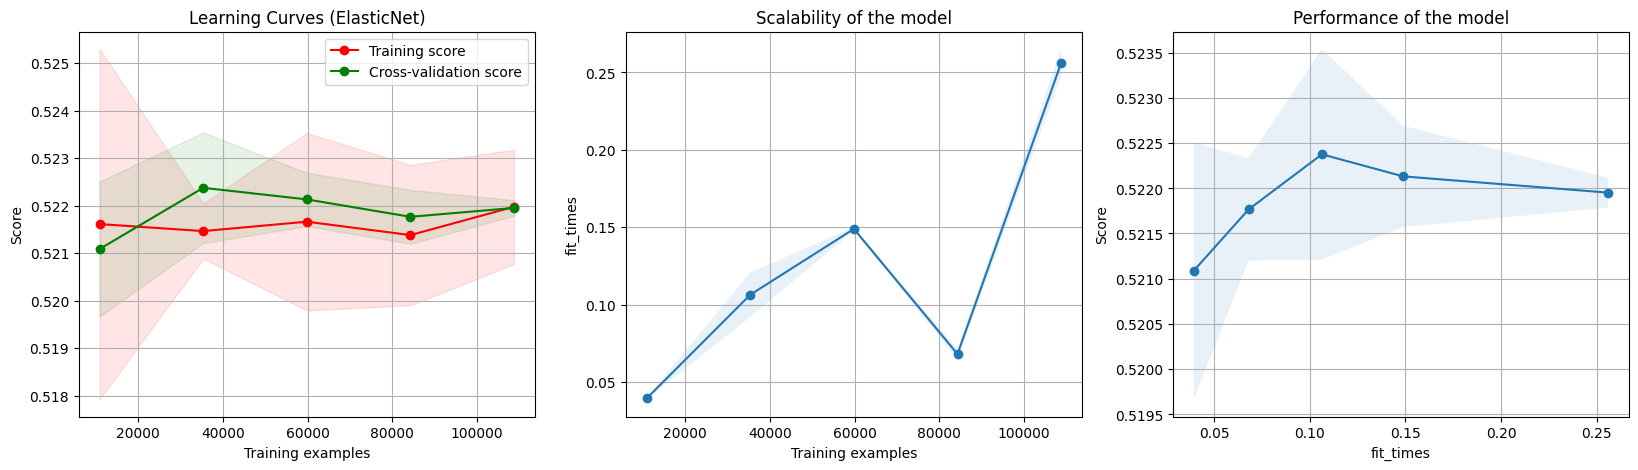

In [170]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_learning_curve(best_en_model, 'Learning Curves (ElasticNet)', X_train, y_train, axes=axes, cv=2, n_jobs=1)

## Random Forrest Regressor


In [171]:
# create a simple LR pipeline
rf_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor())
    ]
)

# simple gridcv params
params = {
    'regressor__max_depth': [None, 5, 10],
    'regressor__min_samples_split': [1, 3],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__max_leaf_nodes': [None, 3, 5]
}

# run grid search
rf_grid = GridSearchCV(
    estimator= rf_pipeline, 
    param_grid=params,
    n_jobs=2, 
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1
)

#fit/run gridsearch
rf_grid.fit(X_train, y_train)

# fit predict and measure best model
best_rf_model = rf_grid.best_estimator_
y_pred = best_rf_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)

tuned_scores_df = pd.concat([tuned_scores_df, pd.DataFrame({
        'model': ['random_forest']*5,
        'scores': np.exp(rmse)
    })])

print(f'Best Params for LR model: {rf_grid.best_params_}')
print(f'RMSE for LR transformed back: {np.exp(rmse)}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/Users/danielcoles/Documents/Code/dc_accelerator/venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/danielcoles/Documents/Code/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
90 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/danielcoles/Documents/Code/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fi

Best Params for LR model: {'regressor__max_depth': None, 'regressor__max_leaf_nodes': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 3}
RMSE for LR transformed back: 5.4013993900437285


<module 'matplotlib.pyplot' from '/Users/danielcoles/Documents/Code/dc_accelerator/venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

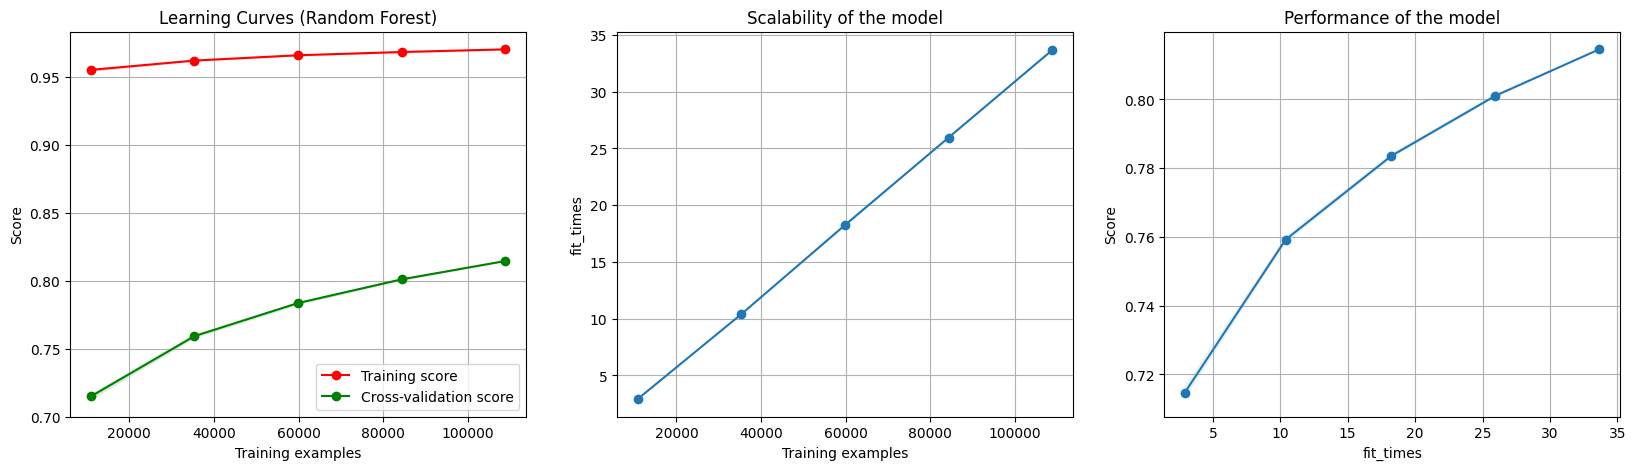

In [172]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_learning_curve(best_rf_model, 'Learning Curves (Random Forest)', X_train, y_train, axes=axes, cv=2, n_jobs=1)

## Gradient Boost Regressor

In [173]:
# create a simple LR pipeline
gb_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('regressor', GradientBoostingRegressor())
    ]
)

# simple gridcv params
params = {
    'regressor__n_estimators': [20, 50, 100],
    'regressor__min_samples_split': [2, 3],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__max_leaf_nodes': [None, 3, 5]
}

# run grid search
gb_grid = GridSearchCV(
    estimator= gb_pipeline, 
    param_grid=params,
    n_jobs=2, 
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1
)

#fit/run gridsearch
gb_grid.fit(X_train, y_train)

# fit predict and measure best model
best_gb_model = gb_grid.best_estimator_
y_pred = best_gb_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)

tuned_scores_df = pd.concat([tuned_scores_df, pd.DataFrame({
        'model': ['gradient_boost']*5,
        'scores': np.exp(rmse)
    })])

print(f'Best Params for LR model: {gb_grid.best_params_}')
print(f'RMSE for LR transformed back: {np.exp(rmse)}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params for LR model: {'regressor__max_leaf_nodes': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}
RMSE for LR transformed back: 11.04697997408299


<module 'matplotlib.pyplot' from '/Users/danielcoles/Documents/Code/dc_accelerator/venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

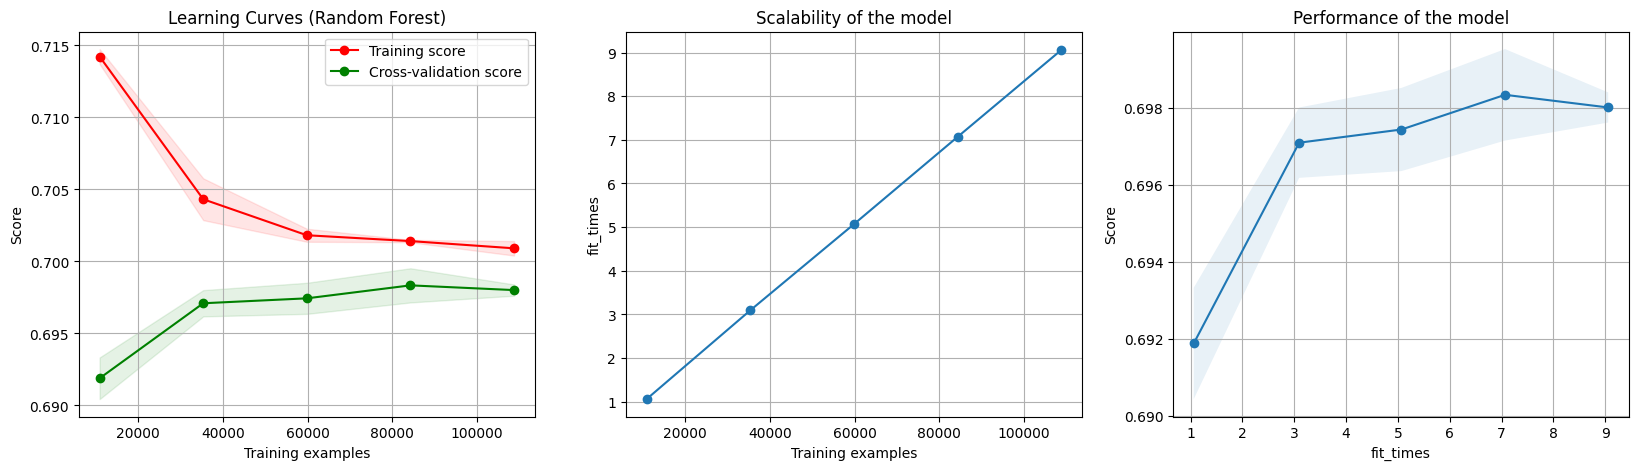

In [174]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_learning_curve(best_gb_model, 'Learning Curves (Random Forest)', X_train, y_train, axes=axes, cv=2, n_jobs=1)

Can we get a plot a box diagram of the new tuned 'best model' scores and see how they compare to the old scores?

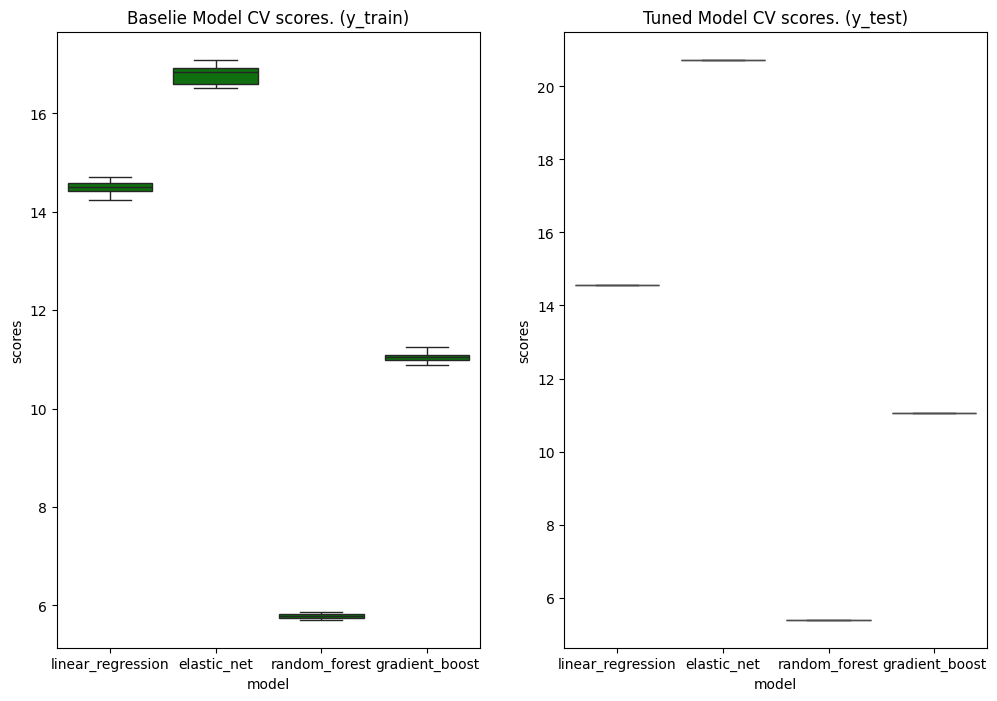

In [175]:
# plot cv scores as a box plot
fig, ax1 = plt.subplots(1, 2, figsize=(12,8))
sns.boxplot(data=cv_scores_df, x='model', y='scores', ax=ax1[0], color= 'green')
ax1[0].set_title('Baselie Model CV scores. (y_train)')

#plot tuned models for comparison
sns.boxplot(data=tuned_scores_df, x='model', y='scores', color='red', ax=ax1[1])
ax1[1].set_title('Tuned Model CV scores. (y_test)')
plt.show()

We can see that even though it takes a long time to hypertune the models, there is only a small amount of improvement in the RMSE scored for each of the models.